# COMP6237 — Topic Modelling visual demo

This notebook is designed to match the lecture flow in **Lecture 11: Topic Modelling (Finding Features II)**.

It uses the same classic 9-document example from the slides for the NMF part, then adds small intuitive demos for:
- LSA recap vs NMF
- NMF soft clustering and topic memberships
- choosing the topic number `k`
- probabilistic topic models
- PLSA intuition
- LDA intuition with Dirichlet priors
- LDA vs PLSA on new documents


In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, TruncatedSVD, LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity
from ipywidgets import interact, IntSlider, FloatSlider

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_colwidth", None)
np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(0)


## 1. Slide: Topic Modelling — Problem

Topic modelling is an **unsupervised document classification** problem, similar to clustering.
A document can belong to **more than one topic**.


In [139]:
doc_names = ["m1","m2","m3","m4","m5","g1","g2","g3","g4"]
docs = [
    "Human machine interface for ABC computer applications",
    "A survey of user opinion of computer system response time",
    "The EPS user interface management system",
    "System and human system engineering testing of EPS",
    "Relation of user perceived response time to error measurement",
    "The generation of random binary ordered trees",
    "The intersection graph of paths in trees",
    "Graph minors IV widths of trees and well quasi ordering",
    "Graph minors a survey",
]
df_docs = pd.DataFrame({"doc": doc_names, "title": docs})
display(df_docs)


,doc,title
0,m1,Human machine interface for ABC computer applications
1,m2,A survey of user opinion of computer system response time
2,m3,The EPS user interface management system
3,m4,System and human system engineering testing of EPS
4,m5,Relation of user perceived response time to error measurement
5,g1,The generation of random binary ordered trees
6,g2,The intersection graph of paths in trees
7,g3,Graph minors IV widths of trees and well quasi ordering
8,g4,Graph minors a survey


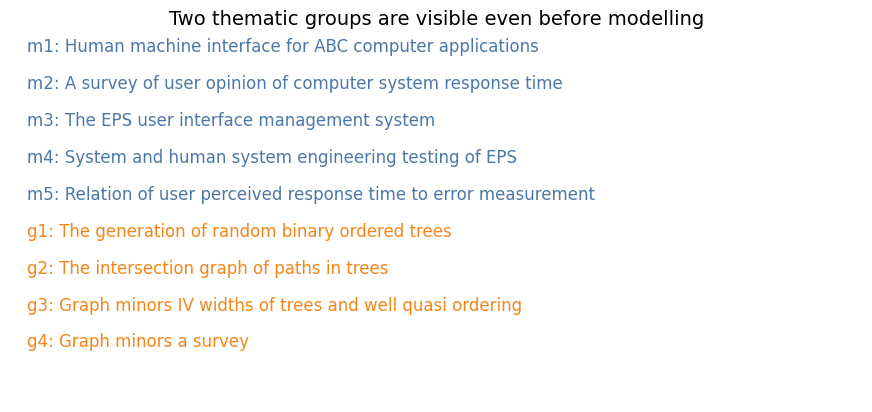

In [140]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.axis("off")
for i, (name, text) in enumerate(zip(doc_names, docs)):
    color = "#4C78A8" if name.startswith("m") else "#F58518"
    ax.text(0.02, 0.95 - i*0.1, f"{name}: {text}", fontsize=12, color=color, transform=ax.transAxes)
ax.set_title("Two thematic groups are visible even before modelling", fontsize=14)
plt.show()


## 2. Slide: LSA recap — linear mixtures can be hard to interpret

We build the same TF–IDF matrix used in the semantic-spaces lecture, then compare **SVD** and **NMF**.


In [141]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=12,
    sublinear_tf=True
)
X = tfidf.fit_transform(docs).toarray().T   # words x docs
terms = tfidf.get_feature_names_out()

display(pd.DataFrame(X, index=terms, columns=doc_names).round(2))


,m1,m2,m3,m4,m5,g1,g2,g3,g4
computer,0.58,0.46,0.00,0.00,0.00,0.0,0.00,0.00,0.00
eps,0.00,0.00,0.60,0.71,0.00,0.0,0.00,0.00,0.00
graph,0.00,0.00,0.00,0.00,0.00,0.0,0.71,0.55,0.52
human,0.58,0.00,0.00,0.71,0.00,0.0,0.00,0.00,0.00
interface,0.58,0.00,0.60,0.00,0.00,0.0,0.00,0.00,0.00
minors,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.63,0.60
perceived,0.00,0.00,0.00,0.00,0.58,0.0,0.00,0.00,0.00
response,0.00,0.46,0.00,0.00,0.49,0.0,0.00,0.00,0.00
survey,0.00,0.46,0.00,0.00,0.00,0.0,0.00,0.00,0.60
time,0.00,0.46,0.00,0.00,0.49,0.0,0.00,0.00,0.00


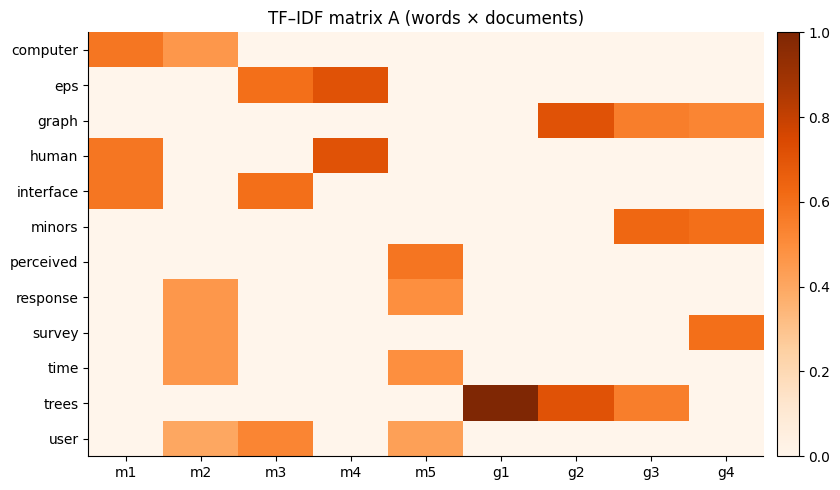

In [142]:
fig, ax = plt.subplots(figsize=(8.5, 5))
im = ax.imshow(X, cmap="Oranges", aspect="auto")
ax.set_yticks(np.arange(len(terms)))
ax.set_yticklabels(terms)
ax.set_xticks(np.arange(len(doc_names)))
ax.set_xticklabels(doc_names)
ax.set_title("TF–IDF matrix A (words × documents)")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()


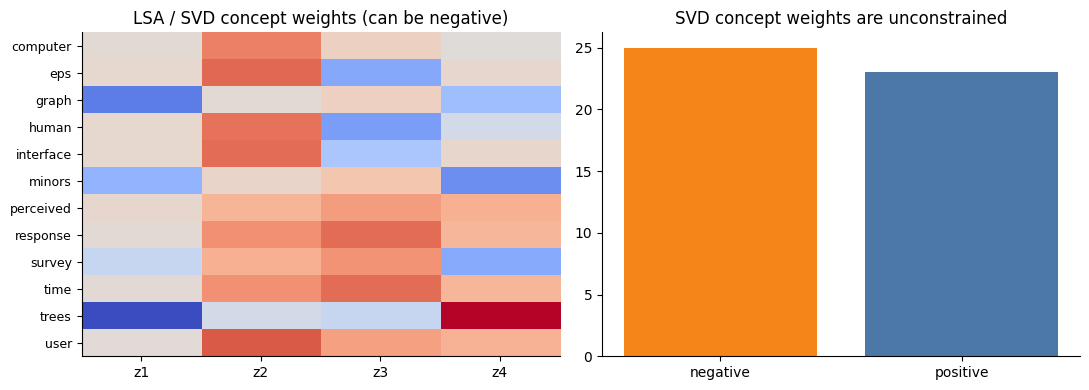

In [143]:
U, s, VT = np.linalg.svd(X, full_matrices=False)
r = 4
Ur = U[:, :r]
Sigmar = np.diag(s[:r])
VTr = VT[:r, :]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(Ur, cmap="coolwarm", aspect="auto")
axes[0].set_title("LSA / SVD concept weights (can be negative)")
axes[0].set_yticks(np.arange(len(terms)))
axes[0].set_yticklabels(terms, fontsize=9)
axes[0].set_xticks(np.arange(r))
axes[0].set_xticklabels([f"z{i+1}" for i in range(r)])

axes[1].bar(["negative", "positive"], [(Ur < 0).sum(), (Ur > 0).sum()], color=["#F58518", "#4C78A8"])
axes[1].set_title("SVD concept weights are unconstrained")
plt.tight_layout()
plt.show()


## 3. Slide: NMF — topic modelling with non-negative factors

Now we factorise the same matrix as

\[
A \approx W H
\]

where:
- `W` = word-to-topic weights
- `H` = topic memberships of documents


In [144]:
nmf_model = NMF(n_components=4, init="nndsvda", random_state=0, max_iter=1000)
W = nmf_model.fit_transform(X)   # words x topics
H = nmf_model.components_        # topics x docs
A_hat = W @ H

print("A shape:", X.shape)
print("W shape:", W.shape)
print("H shape:", H.shape)
print("Reconstruction error:", np.linalg.norm(X - A_hat))


A shape: (12, 9)
W shape: (12, 4)
H shape: (4, 9)
Reconstruction error: 1.393241007835989


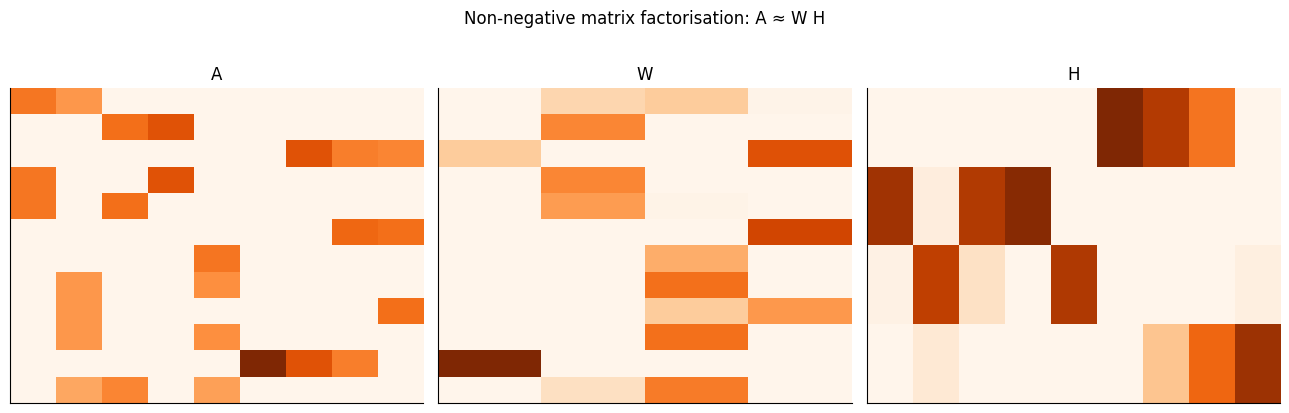

In [145]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, M, ttl in zip(axes, [X, W, H], ["A", "W", "H"]):
    im = ax.imshow(M, cmap="Oranges", aspect="auto")
    ax.set_title(ttl)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Non-negative matrix factorisation: A ≈ W H", y=1.02)
plt.tight_layout()
plt.show()


## 4. Slide: What do the NMF factors mean?

`W` shows **which words define each topic**, and `H` shows **how much each document belongs to each topic**.


In [146]:
def top_terms_per_topic(W, terms, topn=5):
    rows = []
    for k in range(W.shape[1]):
        idx = np.argsort(W[:, k])[::-1][:topn]
        rows.append({
            "topic": f"z{k+1}",
            "top words": ", ".join([terms[i] for i in idx]),
        })
    return pd.DataFrame(rows)

display(top_terms_per_topic(W, terms, 5))


,topic,top words
0,z1,"trees, graph, user, time, survey"
1,z2,"human, eps, interface, computer, user"
2,z3,"time, response, user, perceived, survey"
3,z4,"minors, graph, survey, computer, user"


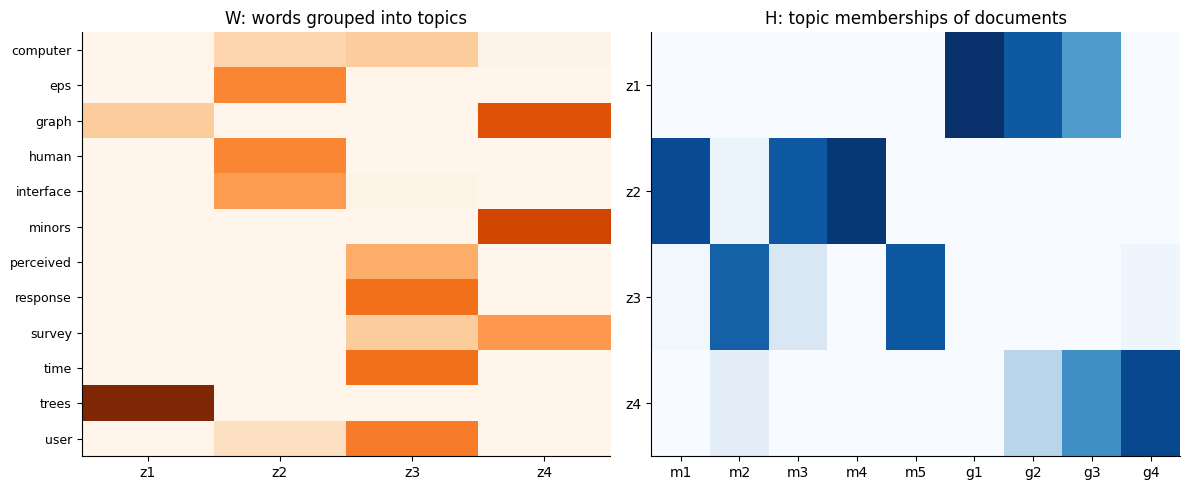

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(W, cmap="Oranges", aspect="auto")
axes[0].set_title("W: words grouped into topics")
axes[0].set_yticks(np.arange(len(terms)))
axes[0].set_yticklabels(terms, fontsize=9)
axes[0].set_xticks(np.arange(W.shape[1]))
axes[0].set_xticklabels([f"z{i+1}" for i in range(W.shape[1])])

axes[1].imshow(H, cmap="Blues", aspect="auto")
axes[1].set_title("H: topic memberships of documents")
axes[1].set_yticks(np.arange(H.shape[0]))
axes[1].set_yticklabels([f"z{i+1}" for i in range(H.shape[0])])
axes[1].set_xticks(np.arange(len(doc_names)))
axes[1].set_xticklabels(doc_names)

plt.tight_layout()
plt.show()


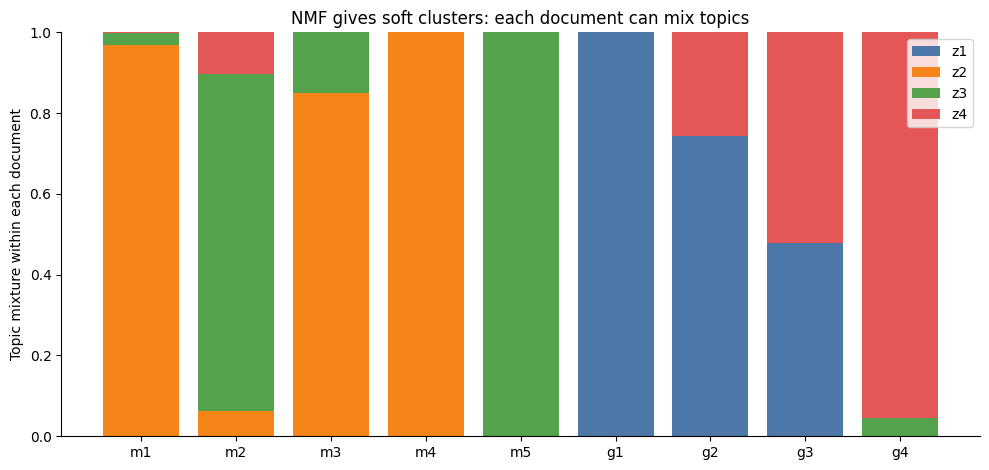

In [148]:
# topic memberships as stacked bars (soft clustering intuition)
topic_names = [f"z{i+1}" for i in range(H.shape[0])]
fig, ax = plt.subplots(figsize=(10, 4.8))
bottom = np.zeros(H.shape[1])
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]
for i in range(H.shape[0]):
    vals = H[i] / H[:, :].sum(axis=0)
    ax.bar(doc_names, vals, bottom=bottom, label=topic_names[i], color=colors[i % len(colors)])
    bottom += vals
ax.set_ylim(0, 1)
ax.set_ylabel("Topic mixture within each document")
ax.set_title("NMF gives soft clusters: each document can mix topics")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Slide: NMF examples — using the same 9-document example from the slides

This interactive cell changes the number of topics and updates `W` and `H`.


In [149]:
def show_nmf_with_k(k=4):
    model = NMF(n_components=k, init="nndsvda", random_state=0, max_iter=1000)
    Wk = model.fit_transform(X)
    Hk = model.components_
    Ahat = Wk @ Hk

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, M, ttl in zip(axes, [X, Wk, Hk], ["A", f"W (k={k})", f"H (k={k})"]):
        ax.imshow(M, cmap="Oranges", aspect="auto")
        ax.set_title(ttl)
        ax.set_xticks([])
        ax.set_yticks([])
    plt.suptitle(f"NMF with k={k} topics | reconstruction error={np.linalg.norm(X-Ahat):.3f}", y=1.02)
    plt.tight_layout()
    plt.show()

interact(show_nmf_with_k, k=IntSlider(min=2, max=6, step=1, value=4, description="topics"));


interactive(children=(IntSlider(value=4, description='topics', max=6, min=2), Output()), _dom_classes=('widget…

## 6. Slide: How are W and H learned?

NMF is fit iteratively by minimizing a cost such as squared error or KL divergence.
We visualise the effect through the decreasing reconstruction error.


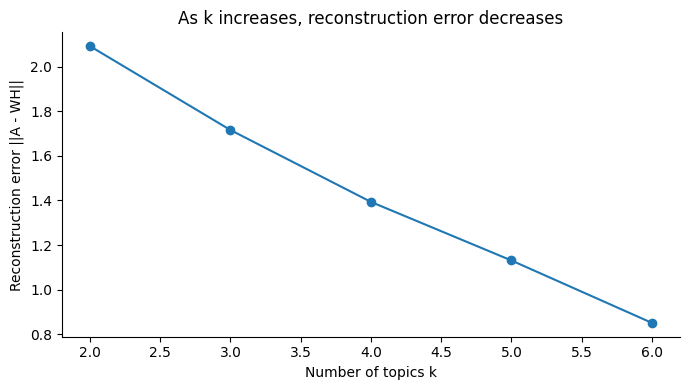

In [150]:
ks = range(2, 7)
errors = []
for k in ks:
    model = NMF(n_components=k, init="nndsvda", random_state=0, max_iter=1000)
    Wk = model.fit_transform(X)
    Hk = model.components_
    errors.append(np.linalg.norm(X - Wk @ Hk))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ks), errors, marker="o")
ax.set_xlabel("Number of topics k")
ax.set_ylabel("Reconstruction error ||A - WH||")
ax.set_title("As k increases, reconstruction error decreases")
plt.tight_layout()
plt.show()


## 7. Slide: Choosing the reduced dimensionality / number of topics

A common practical question is: what value of `k` should we use?
One clue is reconstruction error; another is stability across runs.


In [151]:
def dominant_topic_assignments(k=4, seed=0):
    model = NMF(n_components=k, init="random", random_state=seed, max_iter=1000)
    Hk = model.fit_transform(X.T).T   # docs x k -> transpose to k x docs feel
    return np.argmax(Hk.T, axis=1)

stability_rows = []
for k in range(2, 7):
    assigns = []
    for seed in [0, 1, 2, 3, 4]:
        model = NMF(n_components=k, init="random", random_state=seed, max_iter=1000)
        Wk = model.fit_transform(X)
        Hk = model.components_
        assigns.append(np.argmax(Hk, axis=0))
    agrees = []
    for i in range(len(assigns)-1):
        agrees.append(np.mean(assigns[i] == assigns[i+1]))
    stability_rows.append({"k": k, "avg agreement across runs": np.mean(agrees)})

stability_df = pd.DataFrame(stability_rows)
display(stability_df)


,k,avg agreement across runs
0,2,0.250000
1,3,0.416667
2,4,0.166667
3,5,0.222222
4,6,0.222222


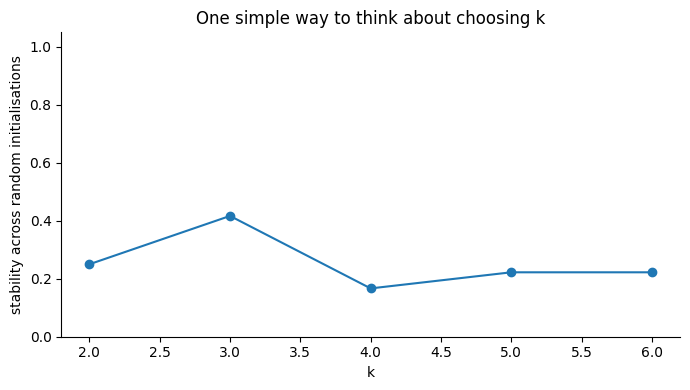

In [152]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(stability_df["k"], stability_df["avg agreement across runs"], marker="o")
ax.set_ylim(0, 1.05)
ax.set_xlabel("k")
ax.set_ylabel("stability across random initialisations")
ax.set_title("One simple way to think about choosing k")
plt.tight_layout()
plt.show()


## 8. Slide: Probabilistic topic models — core intuition

Now switch from matrix factorisation to a probabilistic view:

- a document is a **mixture of topics**
- a topic is a **distribution over words**
- each word token is drawn from a topic


In [153]:
topic_word = pd.DataFrame({
    "topic_A": [0.30, 0.25, 0.20, 0.15, 0.10, 0.00],
    "topic_B": [0.00, 0.00, 0.05, 0.10, 0.35, 0.50],
}, index=["user","system","response","graph","tree","minors"])

doc_topic = pd.Series({"topic_A": 0.7, "topic_B": 0.3}, name="doc_mix")

display(topic_word.round(2))
display(doc_topic.round(2))


,topic_A,topic_B
user,0.30,0.00
system,0.25,0.00
response,0.20,0.05
graph,0.15,0.10
tree,0.10,0.35
minors,0.00,0.50


topic_A    0.7
topic_B    0.3
Name: doc_mix, dtype: float64

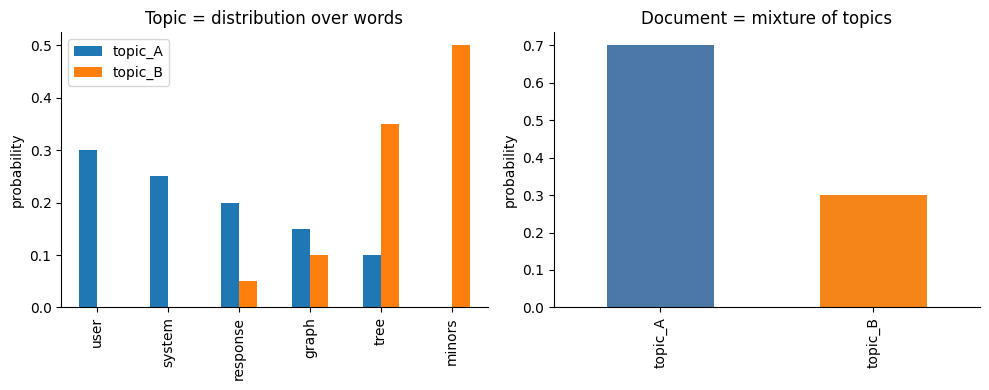

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
topic_word.plot(kind="bar", ax=axes[0])
axes[0].set_title("Topic = distribution over words")
axes[0].set_ylabel("probability")

doc_topic.plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518"])
axes[1].set_title("Document = mixture of topics")
axes[1].set_ylabel("probability")

plt.tight_layout()
plt.show()


In [155]:
# Generate one toy document from the mixture
vocab = topic_word.index.tolist()
topic_names = topic_word.columns.tolist()

def sample_toy_doc(n_words=18, seed=1):
    rng = np.random.default_rng(seed)
    topics = rng.choice(topic_names, size=n_words, p=doc_topic.values)
    words = []
    for z in topics:
        words.append(rng.choice(vocab, p=topic_word[z].values))
    return pd.DataFrame({"topic_chosen": topics, "word_generated": words})

toy_doc = sample_toy_doc(18, seed=2)
display(toy_doc)


,topic_chosen,word_generated
0,topic_A,system
1,topic_A,user
2,topic_B,tree
3,topic_A,system
4,topic_A,graph
5,topic_B,minors
6,topic_A,system
7,topic_A,tree
8,topic_A,system
9,topic_A,response


## 9. Slide: In reality, the topics and topic assignments are hidden

We only see the document words.  
The topic of each word and the document’s mixture proportions are **latent variables** that must be inferred.


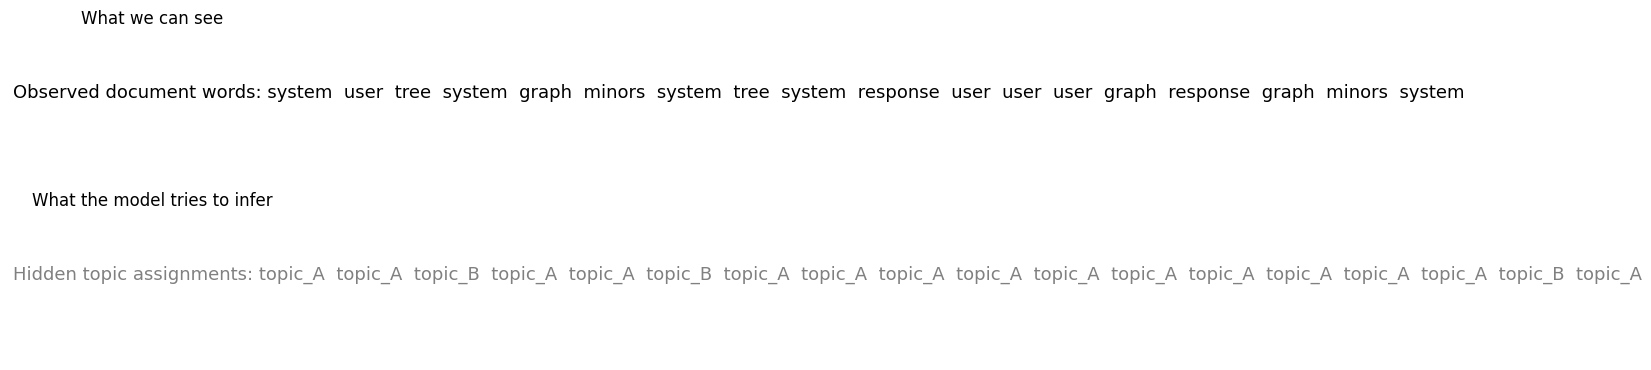

In [156]:
observed = toy_doc["word_generated"].tolist()
hidden_topics = toy_doc["topic_chosen"].tolist()

fig, axes = plt.subplots(2, 1, figsize=(11, 3.8))
axes[0].axis("off")
axes[0].text(0.01, 0.55, "Observed document words: " + "  ".join(observed), fontsize=13)
axes[0].set_title("What we can see")

axes[1].axis("off")
axes[1].text(0.01, 0.55, "Hidden topic assignments: " + "  ".join(hidden_topics), fontsize=13, color="gray")
axes[1].set_title("What the model tries to infer")
plt.tight_layout()
plt.show()


## 10. Slides: PLSA intuition

PLSA models co-occurrence probabilities `P(d,w)` using:
- document-specific topic proportions `P(z|d)`
- topic-specific word distributions `P(w|z)`

The hidden topic acts as a bridge between documents and words.


## 10b. Clean teaching visual: the **common probabilistic idea** behind both PLSA and LDA

Before distinguishing PLSA and LDA, it helps to see their shared story:

- a **document** is a mixture of topics
- a **topic** is a probability distribution over words
- each **word token** is generated by first choosing a hidden topic, then choosing a word from that topic


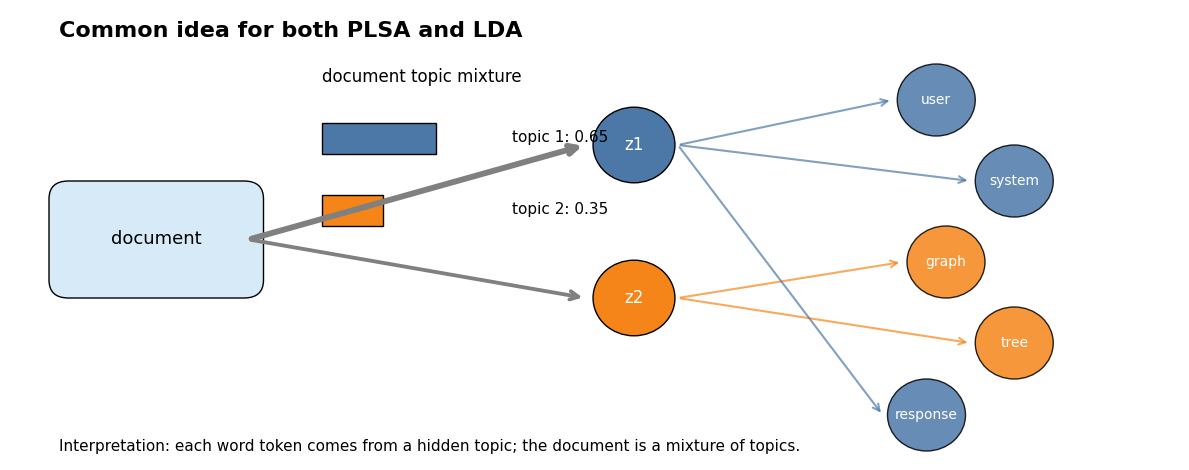

In [157]:
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch, Rectangle

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")

# Document box
doc = FancyBboxPatch((0.6, 2.0), 1.8, 0.9, boxstyle="round,pad=0.2",
                     facecolor="#D6EAF8", edgecolor="black")
ax.add_patch(doc)
ax.text(1.5, 2.45, "document", ha="center", va="center", fontsize=13)

# Topic mixture bars
mix_x = 3.2
mix = [0.65, 0.35]
mix_colors = ["#4C78A8", "#F58518"]
for i, (p, c) in enumerate(zip(mix, mix_colors)):
    ax.add_patch(Rectangle((mix_x, 3.4 - i*0.8), 1.8*p, 0.35, facecolor=c, edgecolor="black"))
    ax.text(mix_x + 1.95, 3.58 - i*0.8, f"topic {i+1}: {p:.2f}", va="center", fontsize=11)
ax.text(mix_x, 4.2, "document topic mixture", fontsize=12)

# Topics
topic_pos = [(6.4, 3.5), (6.4, 1.8)]
for i, ((x,y), c) in enumerate(zip(topic_pos, mix_colors)):
    circ = Circle((x,y), 0.42, facecolor=c, edgecolor="black")
    ax.add_patch(circ)
    ax.text(x, y, f"z{i+1}", ha="center", va="center", color="white", fontsize=12)

# arrows doc -> topics
for (x,y), p, c in zip(topic_pos, mix, mix_colors):
    arr = FancyArrowPatch((2.45, 2.45), (x-0.5, y), arrowstyle="->", mutation_scale=15,
                          lw=1 + 5*p, color="gray")
    ax.add_patch(arr)

# Topic -> words
word_positions = [(9.5, 4.0), (10.3, 3.1), (9.6, 2.2), (10.3, 1.3), (9.4, 0.5)]
word_labels = ["user", "system", "graph", "tree", "response"]
word_topics = [0, 0, 1, 1, 0]
for (x,y), w, z in zip(word_positions, word_labels, word_topics):
    circ = Circle((x,y), 0.4, facecolor=mix_colors[z], alpha=0.85, edgecolor="black")
    ax.add_patch(circ)
    ax.text(x, y, w, ha="center", va="center", color="white", fontsize=10)
    arr = FancyArrowPatch((topic_pos[z][0]+0.45, topic_pos[z][1]), (x-0.45, y),
                          arrowstyle="->", mutation_scale=12, lw=1.5, color=mix_colors[z], alpha=0.7)
    ax.add_patch(arr)

ax.text(0.5, 4.7, "Common idea for both PLSA and LDA", fontsize=16, weight="bold")
ax.text(0.5, 0.1, "Interpretation: each word token comes from a hidden topic; the document is a mixture of topics.", fontsize=11)
plt.tight_layout()
plt.show()


## 10c. Clean teaching visual: **PLSA**

PLSA learns a **separate topic mixture for each training document**.

So every training document has its own `P(z|d)`, and words are generated through that document-specific mixture.


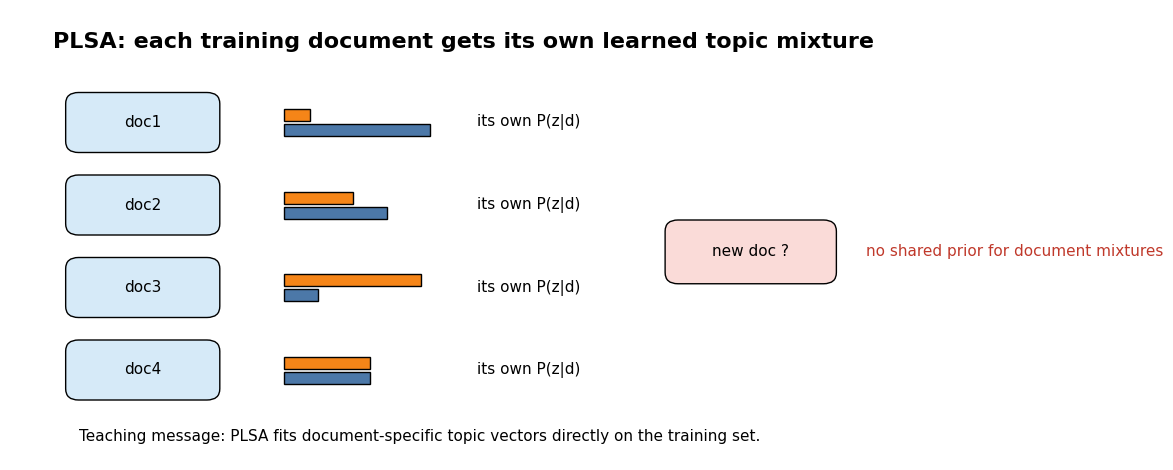

In [158]:
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")

ax.text(0.5, 5.5, "PLSA: each training document gets its own learned topic mixture", fontsize=16, weight="bold")

doc_y = [4.5, 3.4, 2.3, 1.2]
doc_names_demo = ["doc1", "doc2", "doc3", "doc4"]
mixtures = [
    [0.85, 0.15],
    [0.60, 0.40],
    [0.20, 0.80],
    [0.50, 0.50],
]
colors = ["#4C78A8", "#F58518"]

for y, name, mix in zip(doc_y, doc_names_demo, mixtures):
    dbox = FancyBboxPatch((0.8, y-0.25), 1.5, 0.5, boxstyle="round,pad=0.15", facecolor="#D6EAF8", edgecolor="black")
    ax.add_patch(dbox)
    ax.text(1.55, y, name, ha="center", va="center", fontsize=11)

    ax.add_patch(Rectangle((3.2, y-0.18), 2.0*mix[0], 0.16, facecolor=colors[0], edgecolor="black"))
    ax.add_patch(Rectangle((3.2, y+0.02), 2.0*mix[1], 0.16, facecolor=colors[1], edgecolor="black"))
    ax.text(5.45, y, "its own P(z|d)", va="center", fontsize=11)

# new doc issue
ndoc = FancyBboxPatch((7.8, 2.5), 1.7, 0.55, boxstyle="round,pad=0.15", facecolor="#FADBD8", edgecolor="black")
ax.add_patch(ndoc)
ax.text(8.65, 2.78, "new doc ?", ha="center", va="center", fontsize=11)
ax.text(10.0, 2.78, "no shared prior for document mixtures", fontsize=11, color="#C0392B", va="center")

ax.text(0.8, 0.25, "Teaching message: PLSA fits document-specific topic vectors directly on the training set.", fontsize=11)
plt.tight_layout()
plt.show()


In [159]:
# Use count data for simple probabilistic models
cv = CountVectorizer(stop_words="english", max_features=15)
C = cv.fit_transform(docs).toarray().T   # words x docs
words_plsa = cv.get_feature_names_out()

display(pd.DataFrame(C, index=words_plsa, columns=doc_names))


,m1,m2,m3,m4,m5,g1,g2,g3,g4
abc,1,0,0,0,0,0,0,0,0
computer,1,1,0,0,0,0,0,0,0
eps,0,0,1,1,0,0,0,0,0
graph,0,0,0,0,0,0,1,1,1
human,1,0,0,1,0,0,0,0,0
interface,1,0,1,0,0,0,0,0,0
minors,0,0,0,0,0,0,0,1,1
perceived,0,0,0,0,1,0,0,0,0
quasi,0,0,0,0,0,0,0,1,0
relation,0,0,0,0,1,0,0,0,0


In [160]:
# Simple toy PLSA-style decomposition from NMF-normalization intuition
plsa_like = NMF(n_components=3, init="nndsvda", random_state=0, max_iter=1000)
Wc = plsa_like.fit_transform(C.astype(float))  # words x topics
Hc = plsa_like.components_                     # topics x docs

Pw_z = Wc / Wc.sum(axis=0, keepdims=True)
Pz_d = Hc / Hc.sum(axis=0, keepdims=True)

display(pd.DataFrame(Pw_z, index=words_plsa, columns=[f"z{i+1}" for i in range(Pw_z.shape[1])]).round(3))
display(pd.DataFrame(Pz_d, index=[f"z{i+1}" for i in range(Pz_d.shape[0])], columns=doc_names).round(3))


,z1,z2,z3
abc,0.000,0.000,0.150
computer,0.083,0.000,0.154
eps,0.004,0.000,0.162
graph,0.000,0.304,0.000
human,0.000,0.000,0.226
interface,0.000,0.000,0.237
minors,0.000,0.223,0.000
perceived,0.101,0.000,0.000
quasi,0.000,0.133,0.000
relation,0.101,0.000,0.000


,m1,m2,m3,m4,m5,g1,g2,g3,g4
z1,0.0,0.891,0.306,0.0,1.0,0.0,0.0,0.0,0.16
z2,0.0,0.034,0.000,0.0,0.0,1.0,1.0,1.0,0.84
z3,1.0,0.075,0.694,1.0,0.0,0.0,0.0,0.0,0.00


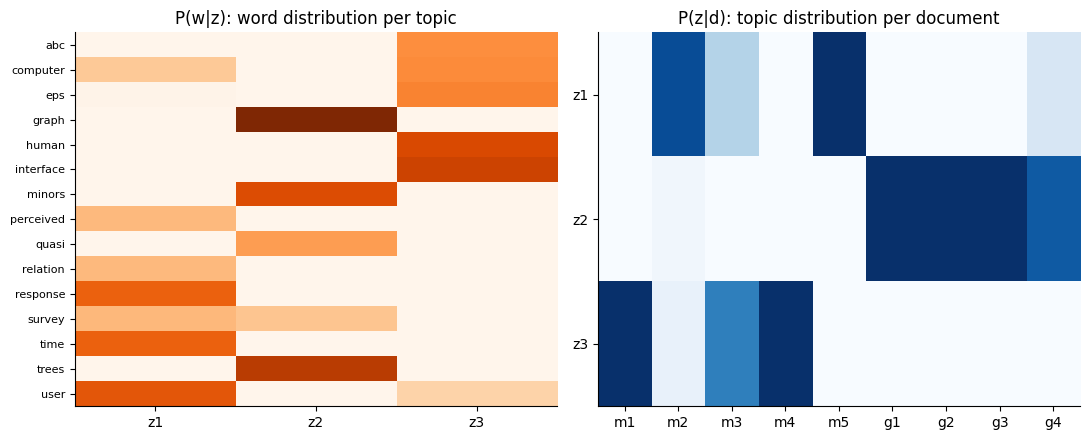

In [161]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(Pw_z, cmap="Oranges", aspect="auto")
axes[0].set_title("P(w|z): word distribution per topic")
axes[0].set_yticks(np.arange(len(words_plsa)))
axes[0].set_yticklabels(words_plsa, fontsize=8)
axes[0].set_xticks(np.arange(Pw_z.shape[1]))
axes[0].set_xticklabels([f"z{i+1}" for i in range(Pw_z.shape[1])])

axes[1].imshow(Pz_d, cmap="Blues", aspect="auto")
axes[1].set_title("P(z|d): topic distribution per document")
axes[1].set_yticks(np.arange(Pz_d.shape[0]))
axes[1].set_yticklabels([f"z{i+1}" for i in range(Pz_d.shape[0])])
axes[1].set_xticks(np.arange(len(doc_names)))
axes[1].set_xticklabels(doc_names)
plt.tight_layout()
plt.show()


## 11. Why PLSA is incomplete at the document level

In PLSA:
- each training document gets its own topic-mixture vector `P(z|d)`
- but there is **no proper probabilistic prior** over these document-topic vectors
- so there is **no full generative model** for document-level topic mixtures

That leads to two problems:

1. the number of document-level parameters grows with the corpus size  
2. for a new test document, it is unclear how to assign probability without fitting a fresh topic mixture


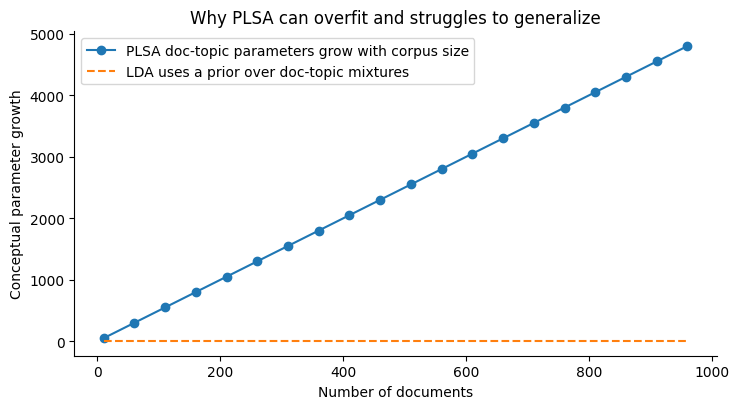

In [162]:
Ds = np.arange(10, 1001, 50)
K = 5
plsa_params = Ds * K                  # one topic vector per doc
lda_params = np.full_like(Ds, K)      # one Dirichlet hyperparameter size idea (conceptual)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(Ds, plsa_params, label="PLSA doc-topic parameters grow with corpus size", marker="o")
ax.plot(Ds, lda_params, label="LDA uses a prior over doc-topic mixtures", linestyle="--")
ax.set_xlabel("Number of documents")
ax.set_ylabel("Conceptual parameter growth")
ax.set_title("Why PLSA can overfit and struggles to generalize")
ax.legend()
plt.tight_layout()
plt.show()


## 12. Slides: LDA — add Dirichlet priors

LDA improves PLSA by putting a **Dirichlet prior** on:
- the topic mixture of each document
- the word distribution of each topic

A Dirichlet is a **distribution over distributions**.


## 12b. Clean teaching visual: **LDA = PLSA + a prior**

LDA keeps the same hidden-topic idea, but adds a **Dirichlet prior** over document-topic mixtures.

So instead of storing one arbitrary mixture for each document, it says:
- first sample a topic mixture `θ` from a prior
- then generate words from that sampled mixture


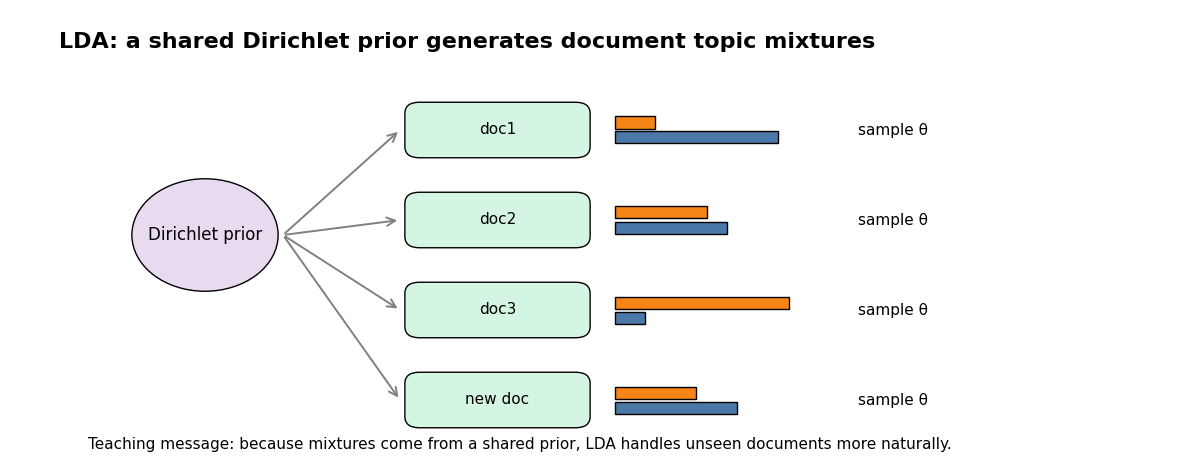

In [163]:
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")

ax.text(0.5, 5.5, "LDA: a shared Dirichlet prior generates document topic mixtures", fontsize=16, weight="bold")

# prior node
prior = Circle((2.0, 3.0), 0.75, facecolor="#E8DAEF", edgecolor="black")
ax.add_patch(prior)
ax.text(2.0, 3.0, "Dirichlet prior", ha="center", va="center", fontsize=12)

# docs and mixtures
doc_y = [4.4, 3.2, 2.0, 0.8]
labels = ["doc1", "doc2", "doc3", "new doc"]
mixtures = [
    [0.80, 0.20],
    [0.55, 0.45],
    [0.15, 0.85],
    [0.60, 0.40],
]
colors = ["#4C78A8", "#F58518"]

for y, label, mix in zip(doc_y, labels, mixtures):
    arr = FancyArrowPatch((2.8, 3.0), (4.0, y), arrowstyle="->", mutation_scale=15, lw=1.4, color="gray")
    ax.add_patch(arr)
    dbox = FancyBboxPatch((4.2, y-0.22), 1.6, 0.44, boxstyle="round,pad=0.15", facecolor="#D5F5E3", edgecolor="black")
    ax.add_patch(dbox)
    ax.text(5.0, y, label, ha="center", va="center", fontsize=11)
    ax.add_patch(Rectangle((6.2, y-0.18), 2.1*mix[0], 0.16, facecolor=colors[0], edgecolor="black"))
    ax.add_patch(Rectangle((6.2, y+0.02), 2.1*mix[1], 0.16, facecolor=colors[1], edgecolor="black"))
    ax.text(8.7, y, "sample θ", va="center", fontsize=11)

ax.text(0.8, 0.15, "Teaching message: because mixtures come from a shared prior, LDA handles unseen documents more naturally.", fontsize=11)
plt.tight_layout()
plt.show()


## 13b. Intuitive comparison: **PLSA vs LDA in one picture**

Both models share the same hidden-topic story.  
The difference is where the document-topic mixture comes from.


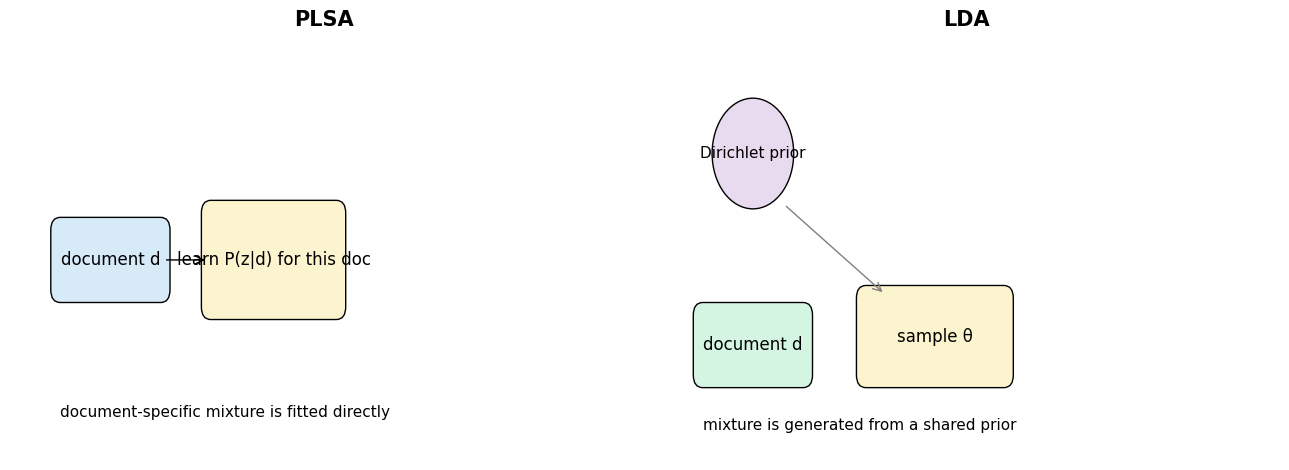

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# PLSA panel
axes[0].set_xlim(0, 10); axes[0].set_ylim(0, 5); axes[0].axis("off")
axes[0].set_title("PLSA", fontsize=15, weight="bold")
dbox = FancyBboxPatch((0.8, 2.0), 1.6, 0.7, boxstyle="round,pad=0.15", facecolor="#D6EAF8", edgecolor="black")
axes[0].add_patch(dbox)
axes[0].text(1.6, 2.35, "document d", ha="center", va="center", fontsize=12)
mix_box = FancyBboxPatch((3.2, 1.8), 2.0, 1.1, boxstyle="round,pad=0.15", facecolor="#FCF3CF", edgecolor="black")
axes[0].add_patch(mix_box)
axes[0].text(4.2, 2.35, "learn P(z|d) for this doc", ha="center", va="center", fontsize=12)
axes[0].add_patch(FancyArrowPatch((2.45, 2.35), (3.15, 2.35), arrowstyle="->", mutation_scale=15))
axes[0].text(0.8, 0.5, "document-specific mixture is fitted directly", fontsize=11)

# LDA panel
axes[1].set_xlim(0, 10); axes[1].set_ylim(0, 5); axes[1].axis("off")
axes[1].set_title("LDA", fontsize=15, weight="bold")
prior = Circle((1.6, 3.6), 0.65, facecolor="#E8DAEF", edgecolor="black")
axes[1].add_patch(prior)
axes[1].text(1.6, 3.6, "Dirichlet prior", ha="center", va="center", fontsize=11)
dbox = FancyBboxPatch((0.8, 1.0), 1.6, 0.7, boxstyle="round,pad=0.15", facecolor="#D5F5E3", edgecolor="black")
axes[1].add_patch(dbox)
axes[1].text(1.6, 1.35, "document d", ha="center", va="center", fontsize=12)
mix_box = FancyBboxPatch((3.4, 1.0), 2.2, 0.9, boxstyle="round,pad=0.15", facecolor="#FCF3CF", edgecolor="black")
axes[1].add_patch(mix_box)
axes[1].text(4.5, 1.45, "sample θ", ha="center", va="center", fontsize=12)
axes[1].add_patch(FancyArrowPatch((2.1, 3.0), (3.7, 1.95), arrowstyle="->", mutation_scale=15, color="gray"))
axes[1].text(0.8, 0.35, "mixture is generated from a shared prior", fontsize=11)

plt.tight_layout()
plt.show()


In [165]:
def dirichlet_samples(alpha, n=400, seed=0):
    rng = np.random.default_rng(seed)
    return rng.dirichlet(alpha, size=n)

samples_sparse = dirichlet_samples([0.2, 0.2, 0.2], 400, 1)
samples_balanced = dirichlet_samples([1.0, 1.0, 1.0], 400, 2)
samples_smooth = dirichlet_samples([5.0, 5.0, 5.0], 400, 3)

display(pd.DataFrame(samples_sparse[:5], columns=["topic1","topic2","topic3"]).round(3))


,topic1,topic2,topic3
0,0.024,0.967,0.009
1,0.203,0.000,0.797
2,0.617,0.343,0.040
3,0.000,0.942,0.057
4,0.006,0.000,0.994


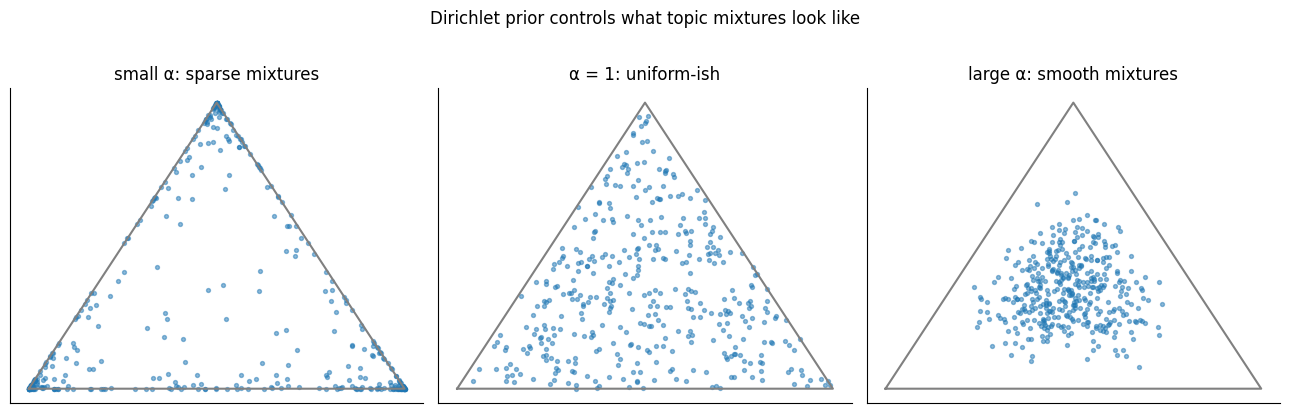

In [166]:
# 2D projection of 3-simplex samples for intuition
def simplex_to_2d(P):
    x = P[:, 0] + 0.5 * P[:, 1]
    y = np.sqrt(3)/2 * P[:, 1]
    return x, y

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
tri_x = [0, 1, 0.5, 0]
tri_y = [0, 0, np.sqrt(3)/2, 0]

for ax, S, ttl in zip(
    axes,
    [samples_sparse, samples_balanced, samples_smooth],
    ["small α: sparse mixtures", "α = 1: uniform-ish", "large α: smooth mixtures"]
):
    x, y = simplex_to_2d(S)
    ax.plot(tri_x, tri_y, color="gray")
    ax.scatter(x, y, s=8, alpha=0.5)
    ax.set_title(ttl)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Dirichlet prior controls what topic mixtures look like", y=1.02)
plt.tight_layout()
plt.show()


## 13. Slides: LDA generative process

For each document:
1. sample a topic mixture `θ`
2. for each word, sample a topic `z`
3. sample the word from that topic’s word distribution `φ_z`


In [167]:
# Tiny LDA-style generation demo
vocab = np.array(["user","system","response","graph","tree","minors","survey"])
phi = np.array([
    [0.30, 0.25, 0.20, 0.05, 0.05, 0.05, 0.10],   # topic 1
    [0.02, 0.03, 0.05, 0.30, 0.30, 0.20, 0.10],   # topic 2
    [0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.40],   # topic 3
])
theta = rng.dirichlet([0.3, 0.3, 0.3])  # sparse topic mixture for one document
z_seq = rng.choice([0,1,2], size=16, p=theta)
w_seq = [rng.choice(vocab, p=phi[z]) for z in z_seq]

print("theta (topic mixture for this document):", np.round(theta, 3))
print("generated topic sequence:", z_seq)
print("generated words:", w_seq)


theta (topic mixture for this document): [0.283 0.    0.717]
generated topic sequence: [2 2 2 2 2 0 2 0 2 0 2 2 2 2 0 0]
generated words: ['survey', 'survey', 'survey', 'graph', 'survey', 'survey', 'survey', 'response', 'survey', 'system', 'system', 'survey', 'minors', 'graph', 'system', 'minors']


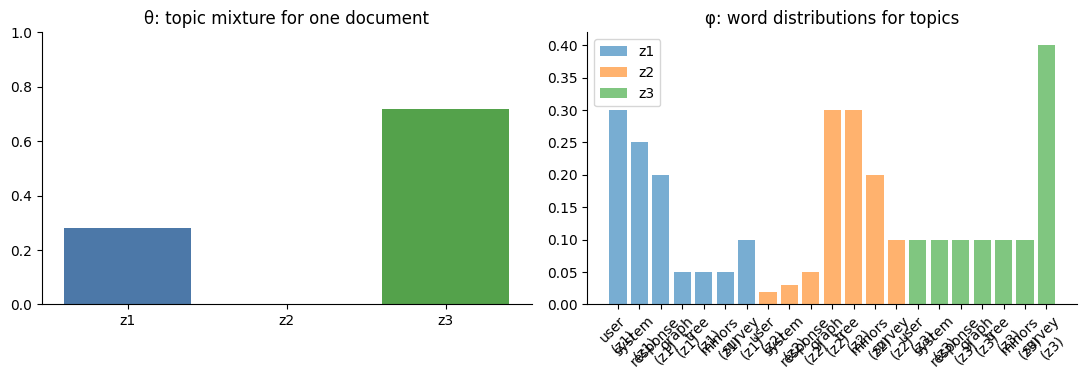

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["z1","z2","z3"], theta, color=["#4C78A8","#F58518","#54A24B"])
axes[0].set_title("θ: topic mixture for one document")
axes[0].set_ylim(0, 1)

for i in range(phi.shape[0]):
    axes[1].bar([f"{w}\n(z{i+1})" for w in vocab], phi[i], alpha=0.6, label=f"z{i+1}")
axes[1].set_title("φ: word distributions for topics")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()
plt.tight_layout()
plt.show()


## 14. Slides: LDA in practice on the same 9 documents

We fit sklearn's LDA to the toy corpus and inspect:
- topic-word distributions
- document-topic mixtures


In [169]:
cv_lda = CountVectorizer(stop_words="english")
X_counts = cv_lda.fit_transform(docs)
lda = LatentDirichletAllocation(n_components=2, random_state=0, learning_method="batch")
doc_topic_lda = lda.fit_transform(X_counts)
topic_word_lda = lda.components_ / lda.components_.sum(axis=1, keepdims=True)
lda_terms = cv_lda.get_feature_names_out()

display(pd.DataFrame(doc_topic_lda, index=doc_names, columns=["topic1","topic2"]).round(3))


,topic1,topic2
m1,0.925,0.075
m2,0.088,0.912
m3,0.887,0.113
m4,0.898,0.102
m5,0.069,0.931
g1,0.089,0.911
g2,0.105,0.895
g3,0.066,0.934
g4,0.129,0.871


In [170]:
def top_words_from_lda(topic_word_matrix, terms, topn=6):
    rows = []
    for k in range(topic_word_matrix.shape[0]):
        idx = np.argsort(topic_word_matrix[k])[::-1][:topn]
        rows.append({
            "topic": f"topic{k+1}",
            "top words": ", ".join([terms[i] for i in idx])
        })
    return pd.DataFrame(rows)

display(top_words_from_lda(topic_word_lda, lda_terms, 6))


,topic,top words
0,topic1,"human, interface, eps, computer, abc, applications"
1,topic2,"trees, graph, user, time, response, minors"


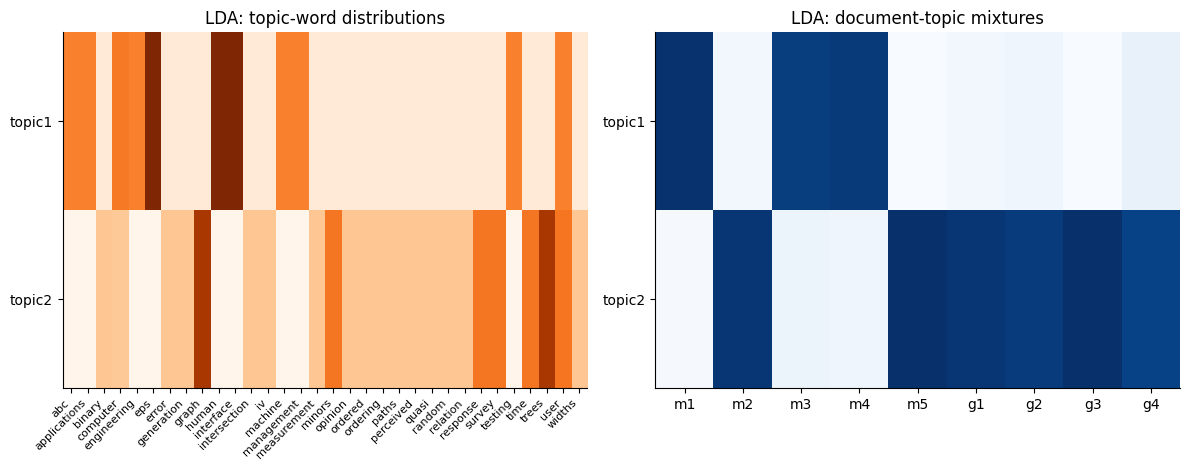

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].imshow(topic_word_lda, cmap="Oranges", aspect="auto")
axes[0].set_title("LDA: topic-word distributions")
axes[0].set_yticks([0,1])
axes[0].set_yticklabels(["topic1","topic2"])
axes[0].set_xticks(np.arange(len(lda_terms)))
axes[0].set_xticklabels(lda_terms, rotation=45, ha="right", fontsize=8)

axes[1].imshow(doc_topic_lda.T, cmap="Blues", aspect="auto")
axes[1].set_title("LDA: document-topic mixtures")
axes[1].set_yticks([0,1])
axes[1].set_yticklabels(["topic1","topic2"])
axes[1].set_xticks(np.arange(len(doc_names)))
axes[1].set_xticklabels(doc_names)

plt.tight_layout()
plt.show()


## 15. Slide: LDA vs PLSA on new documents

LDA is easier to generalize, because new documents can get topic mixtures from the learned prior/model.
PLSA has document-specific parameters tied to the training set.


## 15c. LDA testing is **not from scratch**

At test time, **LDA does not rebuild the whole model**.

Training has already learned:
- the **topic–word distributions**: what each topic looks like
- the **Dirichlet prior**: what document-topic mixtures usually look like

So for a new document, the only missing part is its **document-topic mixture**.

In other words:
- **training** learns the topic system
- **testing** just places the new document inside that topic system


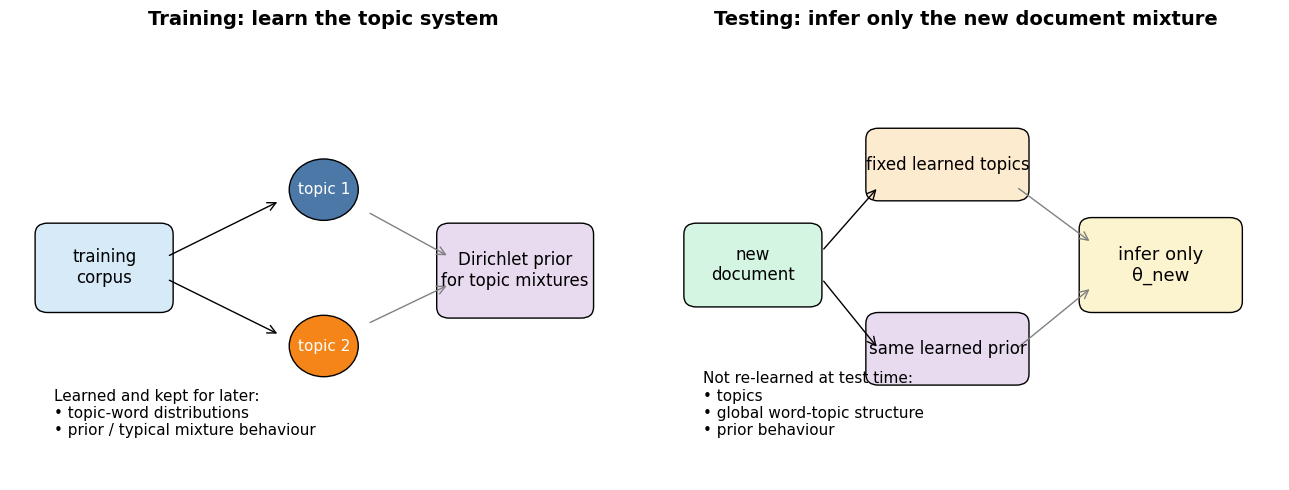

In [172]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- training panel ---
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title("Training: learn the topic system", fontsize=14, weight="bold")

corpus = FancyBboxPatch((0.6, 3.2), 1.8, 1.2, boxstyle="round,pad=0.2",
                        facecolor="#D6EAF8", edgecolor="black")
ax.add_patch(corpus)
ax.text(1.5, 3.8, "training\ncorpus", ha="center", va="center", fontsize=12)

topic1 = Circle((5.0, 5.2), 0.55, facecolor="#4C78A8", edgecolor="black")
topic2 = Circle((5.0, 2.4), 0.55, facecolor="#F58518", edgecolor="black")
ax.add_patch(topic1); ax.add_patch(topic2)
ax.text(5.0, 5.2, "topic 1", ha="center", va="center", color="white", fontsize=11)
ax.text(5.0, 2.4, "topic 2", ha="center", va="center", color="white", fontsize=11)

prior = FancyBboxPatch((7.0, 3.1), 2.1, 1.3, boxstyle="round,pad=0.2",
                       facecolor="#E8DAEF", edgecolor="black")
ax.add_patch(prior)
ax.text(8.05, 3.75, "Dirichlet prior\nfor topic mixtures", ha="center", va="center", fontsize=12)

ax.add_patch(FancyArrowPatch((2.5, 4.0), (4.3, 5.0), arrowstyle="->", mutation_scale=15))
ax.add_patch(FancyArrowPatch((2.5, 3.6), (4.3, 2.6), arrowstyle="->", mutation_scale=15))
ax.add_patch(FancyArrowPatch((5.7, 4.8), (7.0, 4.0), arrowstyle="->", mutation_scale=15, color="gray"))
ax.add_patch(FancyArrowPatch((5.7, 2.8), (7.0, 3.5), arrowstyle="->", mutation_scale=15, color="gray"))

ax.text(0.7, 0.8, "Learned and kept for later:\n• topic-word distributions\n• prior / typical mixture behaviour", fontsize=11)

# --- test panel ---
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title("Testing: infer only the new document mixture", fontsize=14, weight="bold")

newdoc = FancyBboxPatch((0.7, 3.3), 1.8, 1.1, boxstyle="round,pad=0.2",
                        facecolor="#D5F5E3", edgecolor="black")
ax.add_patch(newdoc)
ax.text(1.6, 3.85, "new\ndocument", ha="center", va="center", fontsize=12)

fixed_topics = FancyBboxPatch((3.6, 5.2), 2.2, 0.9, boxstyle="round,pad=0.2",
                              facecolor="#FDEBD0", edgecolor="black")
ax.add_patch(fixed_topics)
ax.text(4.7, 5.65, "fixed learned topics", ha="center", va="center", fontsize=12)

fixed_prior = FancyBboxPatch((3.6, 1.9), 2.2, 0.9, boxstyle="round,pad=0.2",
                             facecolor="#E8DAEF", edgecolor="black")
ax.add_patch(fixed_prior)
ax.text(4.7, 2.35, "same learned prior", ha="center", va="center", fontsize=12)

theta = FancyBboxPatch((7.0, 3.2), 2.2, 1.3, boxstyle="round,pad=0.2",
                       facecolor="#FCF3CF", edgecolor="black")
ax.add_patch(theta)
ax.text(8.1, 3.85, "infer only\nθ_new", ha="center", va="center", fontsize=13)

ax.add_patch(FancyArrowPatch((2.7, 4.1), (3.6, 5.25), arrowstyle="->", mutation_scale=15))
ax.add_patch(FancyArrowPatch((2.7, 3.6), (3.6, 2.35), arrowstyle="->", mutation_scale=15))
ax.add_patch(FancyArrowPatch((5.8, 5.25), (7.0, 4.25), arrowstyle="->", mutation_scale=15, color="gray"))
ax.add_patch(FancyArrowPatch((5.8, 2.35), (7.0, 3.45), arrowstyle="->", mutation_scale=15, color="gray"))

ax.text(0.8, 0.8, "Not re-learned at test time:\n• topics\n• global word-topic structure\n• prior behaviour", fontsize=11)
plt.tight_layout()
plt.show()


## 15d. Why the Dirichlet prior helps estimation

The prior is **not only a sparsity knob**.

It also acts like **regularization**:
- it gives the document-topic vector a sensible default shape
- it prevents very short or noisy documents from producing unstable mixtures
- it lets the estimate use both:
  - **document evidence** (the words in this document)
  - **corpus-level belief** about what topic mixtures usually look like

A useful rough intuition is:

\[
\text{topic proportion} \approx \text{topic evidence from words} + \alpha
\]

so the prior behaves like a small **pseudo-count**.


## 15e. Posterior intuition: likelihood × prior = posterior

In LDA, we are really estimating:

$
P(\theta \mid w) \propto P(w \mid \theta) \, P(\theta)
$

So the inferred document-topic vector $\theta$ is shaped by:

- the **likelihood** $P(w \mid \theta)$: what the words suggest
- the **prior** $P(\theta)$: what mixtures are plausible in general

If a document is long and very clear, the likelihood dominates.

If a document is short or noisy, the prior matters much more.

That is why the prior helps estimation.


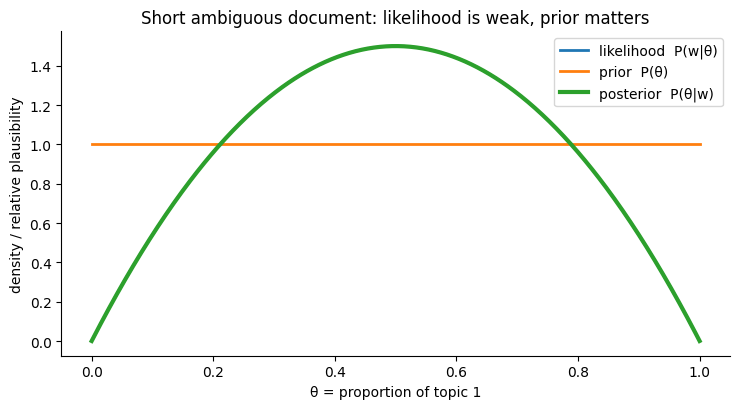

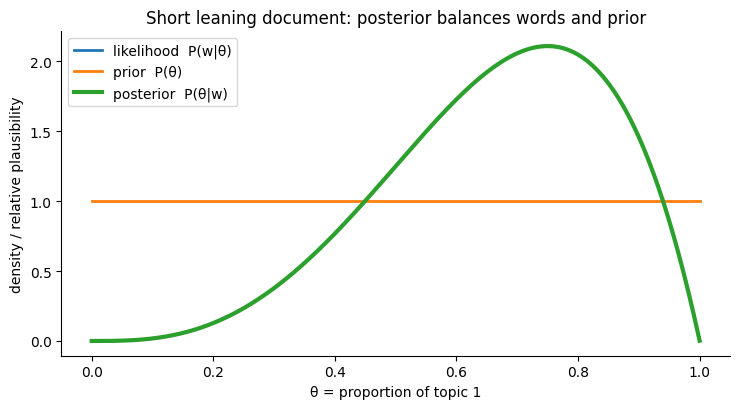

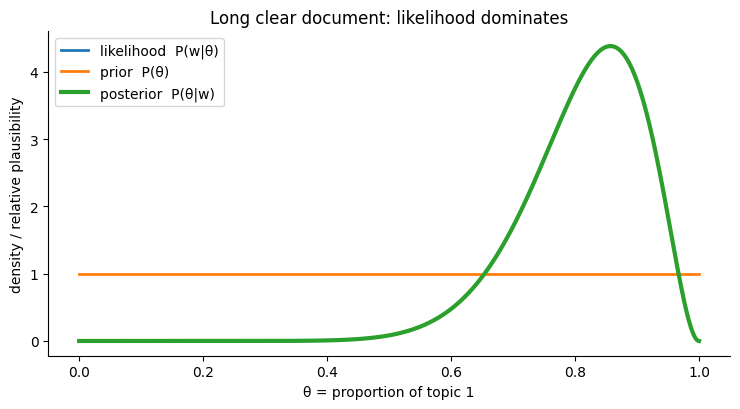

In [173]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(1e-4, 1-1e-4, 600)

def normalize_curve(y):
    y = np.maximum(y, 1e-300)
    area = np.trapz(y, x)
    return y / area

def beta_like_pdf(x, a, b):
    # unnormalized Beta density, enough for shape visualization
    return np.power(x, a-1) * np.power(1-x, b-1)

def posterior_demo(n1, n2, a=1.0, b=1.0, title=""):
    likelihood = normalize_curve(np.power(x, n1) * np.power(1-x, n2))
    prior = normalize_curve(beta_like_pdf(x, a, b))
    posterior = normalize_curve(np.power(x, n1 + a - 1) * np.power(1-x, n2 + b - 1))

    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.plot(x, likelihood, label="likelihood  P(w|θ)", linewidth=2)
    ax.plot(x, prior, label="prior  P(θ)", linewidth=2)
    ax.plot(x, posterior, label="posterior  P(θ|w)", linewidth=3)
    ax.set_xlabel("θ = proportion of topic 1")
    ax.set_ylabel("density / relative plausibility")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Three teaching cases
posterior_demo(n1=1, n2=1, a=1.0, b=1.0, title="Short ambiguous document: likelihood is weak, prior matters")
posterior_demo(n1=3, n2=1, a=1.0, b=1.0, title="Short leaning document: posterior balances words and prior")
posterior_demo(n1=12, n2=2, a=1.0, b=1.0, title="Long clear document: likelihood dominates")


In [ ]:
from ipywidgets import interact, IntSlider, FloatSlider

def interactive_posterior(n1=2, n2=2, alpha1=1.0, alpha2=1.0):
    likelihood = normalize_curve(np.power(x, n1) * np.power(1-x, n2))
    prior = normalize_curve(beta_like_pdf(x, alpha1, alpha2))
    posterior = normalize_curve(np.power(x, n1 + alpha1 - 1) * np.power(1-x, n2 + alpha2 - 1))

    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.plot(x, likelihood, label="likelihood  P(w|θ)", linewidth=2)
    ax.plot(x, prior, label="prior  P(θ)", linewidth=2)
    ax.plot(x, posterior, label="posterior  P(θ|w)", linewidth=3)

    theta_words = n1 / (n1 + n2) if (n1 + n2) > 0 else 0.5
    theta_post = (n1 + alpha1) / (n1 + n2 + alpha1 + alpha2)

    ax.axvline(theta_words, linestyle="--", color="gray", alpha=0.7, label="words-only estimate")
    ax.axvline(theta_post, linestyle="--", color="black", alpha=0.9, label="regularized estimate")

    ax.set_xlabel("θ = proportion of topic 1")
    ax.set_ylabel("density / relative plausibility")
    ax.set_title("Posterior = likelihood × prior")
    ax.legend(loc="upper center", ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"Words-only estimate        ≈ {theta_words:.2f}")
    print(f"Prior-regularized estimate ≈ {theta_post:.2f}")
    print("Interpretation: when evidence is weak, the prior pulls the estimate toward a more plausible mixture.")

interact(
    interactive_posterior,
    n1=IntSlider(min=0, max=15, step=1, value=2, description="topic1 words"),
    n2=IntSlider(min=0, max=15, step=1, value=2, description="topic2 words"),
    alpha1=FloatSlider(min=0.2, max=5.0, step=0.2, value=1.0, description="α1"),
    alpha2=FloatSlider(min=0.2, max=5.0, step=0.2, value=1.0, description="α2"),
);


interactive(children=(IntSlider(value=2, description='topic1 words', max=15), IntSlider(value=2, description='…

## 15f. A direct bridge from the slide to LDA test-time inference

This is the teaching message you can say while running the code:

- the **likelihood** comes from the words in the new document
- the **prior** comes from the learned topic system / prior belief
- the **posterior** is the inferred document-topic vector

So LDA test-time inference is **not from scratch**:
it is just finding the most plausible `θ` for the new document **inside the already learned model**.


,new doc,topic-1 evidence,topic-2 evidence,words-only θ,posterior-like θ
0,response tree,2.6,2.6,"(0.50, 0.50)","(0.50, 0.50)"
1,user survey,4.0,0.5,"(0.89, 0.11)","(0.79, 0.21)"
2,graph tree minors tree,0.4,10.0,"(0.04, 0.96)","(0.10, 0.90)"


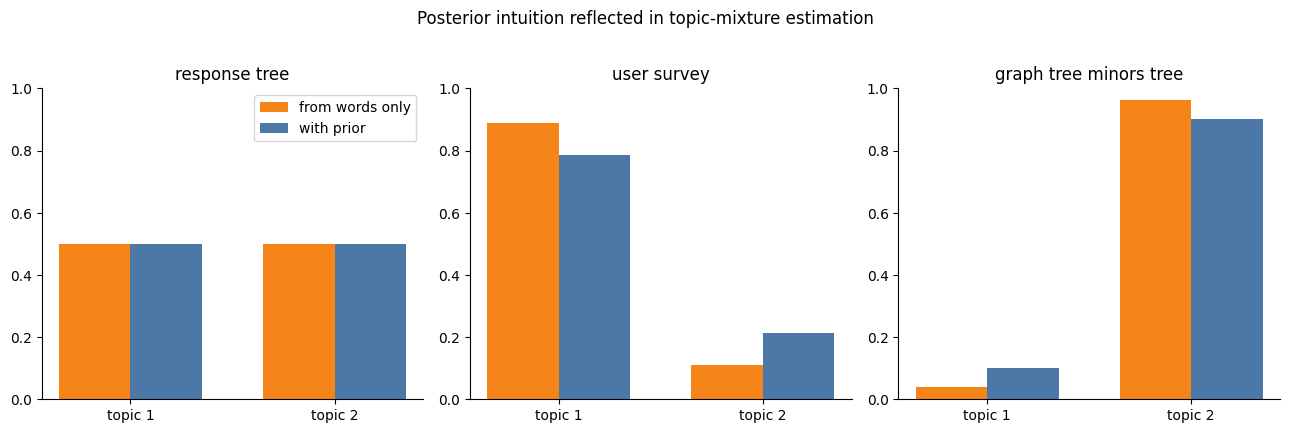

In [175]:

# Same idea using the lecture-style two-topic evidence table
# topic 1 ~ user/system/response ; topic 2 ~ graph/tree/minors

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

word_to_topic_evidence = {
    "user": np.array([3.0, 0.1]),
    "response": np.array([2.5, 0.1]),
    "survey": np.array([1.0, 0.4]),
    "graph": np.array([0.1, 3.0]),
    "tree": np.array([0.1, 2.5]),
    "minors": np.array([0.1, 2.0]),
}

toy_docs = {
    "response tree": ["response", "tree"],
    "user survey": ["user", "survey"],
    "graph tree minors tree": ["graph", "tree", "minors", "tree"],
}

alpha = 0.8
rows = []
for name, words in toy_docs.items():
    evidence = np.zeros(2)
    for w in words:
        evidence += word_to_topic_evidence[w]

    theta_words = evidence / evidence.sum()
    theta_post = (evidence + alpha) / (evidence + alpha).sum()

    rows.append({
        "new doc": name,
        "topic-1 evidence": round(float(evidence[0]), 2),
        "topic-2 evidence": round(float(evidence[1]), 2),
        "words-only θ": f"({theta_words[0]:.2f}, {theta_words[1]:.2f})",
        "posterior-like θ": f"({theta_post[0]:.2f}, {theta_post[1]:.2f})",
    })

df_bridge = pd.DataFrame(rows)
display(df_bridge)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

for ax, (name, words) in zip(axes, toy_docs.items()):
    evidence = np.zeros(2)
    for w in words:
        evidence += word_to_topic_evidence[w]
    theta_words = evidence / evidence.sum()
    theta_post = (evidence + alpha) / (evidence + alpha).sum()

    xloc = np.arange(2)
    width = 0.35
    ax.bar(xloc - width/2, theta_words, width, label="from words only", color="#F58518")
    ax.bar(xloc + width/2, theta_post, width, label="with prior", color="#4C78A8")
    ax.set_xticks(xloc)
    ax.set_xticklabels(["topic 1", "topic 2"])
    ax.set_ylim(0, 1)
    ax.set_title(name)

axes[0].legend()
plt.suptitle("Posterior intuition reflected in topic-mixture estimation", y=1.02)
plt.tight_layout()
plt.show()


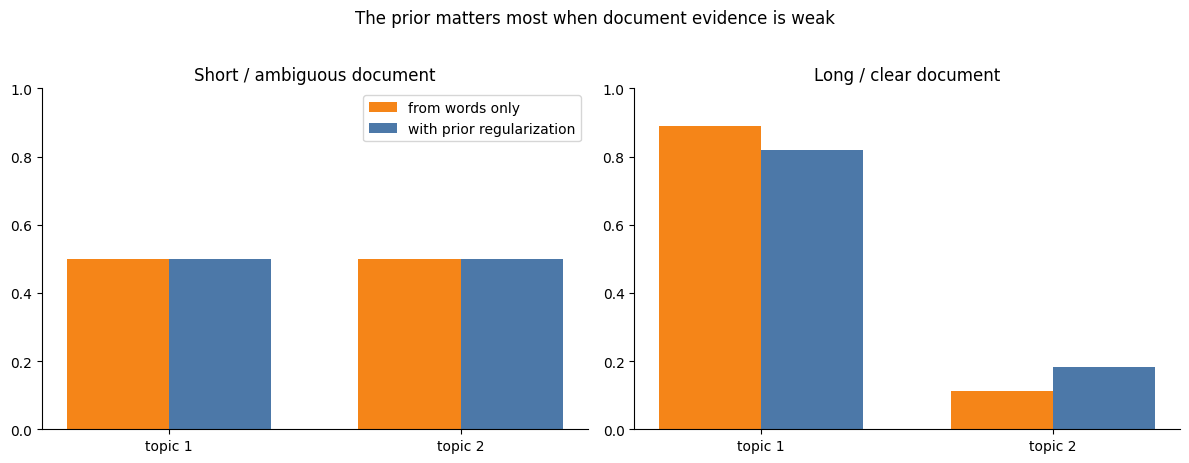

In [176]:
import numpy as np
import matplotlib.pyplot as plt

topics = ["topic 1", "topic 2"]

weak_counts = np.array([1, 1])   # tiny ambiguous evidence
strong_counts = np.array([8, 1]) # strong evidence for topic 1
alpha_reg = 1.0

def normalize(v):
    v = np.array(v, dtype=float)
    return v / v.sum()

weak_no_prior = normalize(weak_counts)
weak_with_prior = normalize(weak_counts + alpha_reg)

strong_no_prior = normalize(strong_counts)
strong_with_prior = normalize(strong_counts + alpha_reg)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(topics))
width = 0.35

axes[0].bar(x - width/2, weak_no_prior, width, label="from words only", color="#F58518")
axes[0].bar(x + width/2, weak_with_prior, width, label="with prior regularization", color="#4C78A8")
axes[0].set_xticks(x)
axes[0].set_xticklabels(topics)
axes[0].set_ylim(0, 1)
axes[0].set_title("Short / ambiguous document")
axes[0].legend()

axes[1].bar(x - width/2, strong_no_prior, width, label="from words only", color="#F58518")
axes[1].bar(x + width/2, strong_with_prior, width, label="with prior regularization", color="#4C78A8")
axes[1].set_xticks(x)
axes[1].set_xticklabels(topics)
axes[1].set_ylim(0, 1)
axes[1].set_title("Long / clear document")

plt.suptitle("The prior matters most when document evidence is weak", y=1.02)
plt.tight_layout()
plt.show()


In [177]:
# A toy example tied to the lecture topics:
# topic 1 ~ user/system/response ; topic 2 ~ graph/tree/minors
word_to_topic_evidence = {
    "user": np.array([3.0, 0.1]),
    "response": np.array([2.5, 0.1]),
    "survey": np.array([1.0, 0.4]),
    "graph": np.array([0.1, 3.0]),
    "tree": np.array([0.1, 2.5]),
    "minors": np.array([0.1, 2.0]),
}

def infer_mixture_from_words(words, alpha=0.5):
    evidence = np.zeros(2)
    for w in words:
        evidence += word_to_topic_evidence[w]
    no_prior = evidence / evidence.sum()
    with_prior = (evidence + alpha) / (evidence + alpha).sum()
    return evidence, no_prior, with_prior

toy_docs = {
    "short ambiguous": ["response", "tree"],
    "short but leaning topic1": ["user", "survey"],
    "clear topic2": ["graph", "tree", "minors", "tree"],
}

rows = []
for name, words in toy_docs.items():
    evidence, no_prior, with_prior = infer_mixture_from_words(words, alpha=0.8)
    rows.append({
        "doc": name,
        "words": ", ".join(words),
        "evidence t1": round(evidence[0], 2),
        "evidence t2": round(evidence[1], 2),
        "mixture from words only": f"({no_prior[0]:.2f}, {no_prior[1]:.2f})",
        "mixture with prior": f"({with_prior[0]:.2f}, {with_prior[1]:.2f})",
    })

display(pd.DataFrame(rows))


,doc,words,evidence t1,evidence t2,mixture from words only,mixture with prior
0,short ambiguous,"response, tree",2.6,2.6,"(0.50, 0.50)","(0.50, 0.50)"
1,short but leaning topic1,"user, survey",4.0,0.5,"(0.89, 0.11)","(0.79, 0.21)"
2,clear topic2,"graph, tree, minors, tree",0.4,10.0,"(0.04, 0.96)","(0.10, 0.90)"


### Classroom takeaway

**LDA does not infer from scratch because the topics and the prior are already learned from training; test-time inference only estimates the new document's topic mixture inside that fixed shared model.**

And the prior helps because it **regularizes** the estimate:
it does not just encourage sparsity, it makes the new document mixture more stable when evidence is weak.


## 15b. Train vs test: how PLSA and LDA behave differently

This section makes the workflow explicit:

- **Training phase**
  - PLSA learns a topic mixture for each training document directly
  - LDA learns topics plus a prior-governed way to generate document mixtures

- **Test phase**
  - PLSA does **not** already have a stored topic mixture for a new document
  - LDA can infer a topic mixture for a new document naturally from the learned model


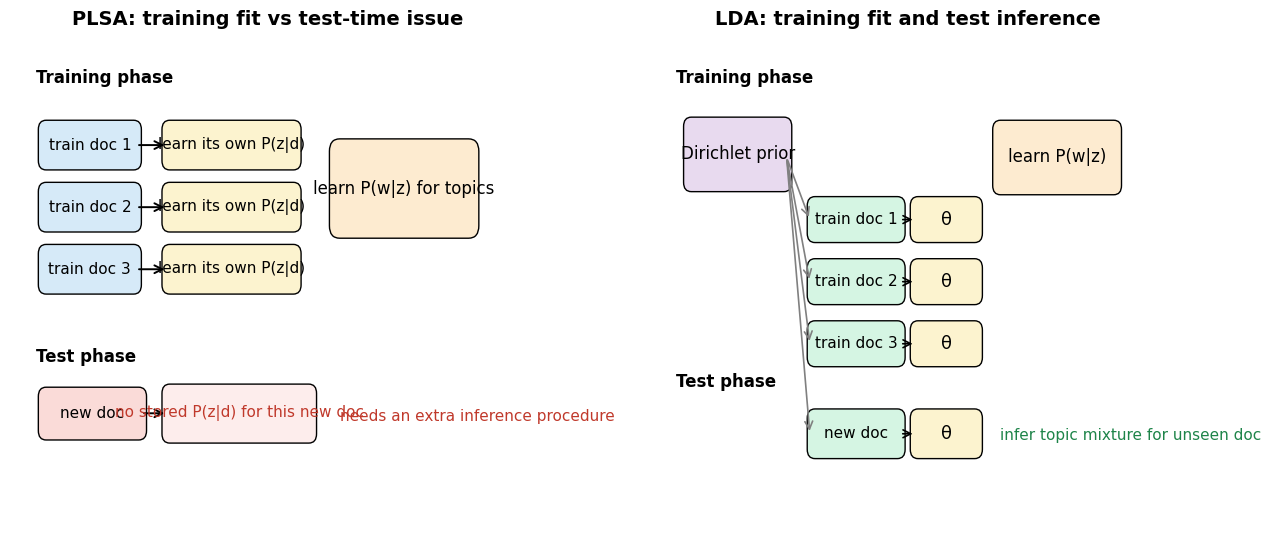

In [178]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ----- PLSA panel -----
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title("PLSA: training fit vs test-time issue", fontsize=14, weight="bold")

# train docs
ax.text(0.5, 7.2, "Training phase", fontsize=12, weight="bold")
for i, y in enumerate([6.2, 5.2, 4.2]):
    d = FancyBboxPatch((0.7, y-0.25), 1.7, 0.5, boxstyle="round,pad=0.15",
                       facecolor="#D6EAF8", edgecolor="black")
    ax.add_patch(d)
    ax.text(1.55, y, f"train doc {i+1}", ha="center", va="center", fontsize=11)

    mix = FancyBboxPatch((3.1, y-0.25), 2.4, 0.5, boxstyle="round,pad=0.15",
                         facecolor="#FCF3CF", edgecolor="black")
    ax.add_patch(mix)
    ax.text(4.3, y, "learn its own P(z|d)", ha="center", va="center", fontsize=11)

    arr = FancyArrowPatch((2.45, y), (3.05, y), arrowstyle="->", mutation_scale=14, lw=1.4)
    ax.add_patch(arr)

# shared topic-word distributions
topic_box = FancyBboxPatch((6.4, 4.9), 2.5, 1.2, boxstyle="round,pad=0.2",
                           facecolor="#FDEBD0", edgecolor="black")
ax.add_patch(topic_box)
ax.text(7.65, 5.5, "learn P(w|z) for topics", ha="center", va="center", fontsize=12)

# test doc
ax.text(0.5, 2.7, "Test phase", fontsize=12, weight="bold")
newd = FancyBboxPatch((0.7, 1.6), 1.8, 0.55, boxstyle="round,pad=0.15",
                      facecolor="#FADBD8", edgecolor="black")
ax.add_patch(newd)
ax.text(1.6, 1.88, "new doc", ha="center", va="center", fontsize=11)

unknown = FancyBboxPatch((3.1, 1.55), 2.7, 0.65, boxstyle="round,pad=0.15",
                         facecolor="#FDEDEC", edgecolor="black")
ax.add_patch(unknown)
ax.text(4.45, 1.88, "no stored P(z|d) for this new doc", ha="center", va="center", fontsize=11, color="#C0392B")

ax.add_patch(FancyArrowPatch((2.55, 1.88), (3.05, 1.88), arrowstyle="->", mutation_scale=14, lw=1.4))
ax.text(6.4, 1.75, "needs an extra inference procedure", fontsize=11, color="#C0392B")

# ----- LDA panel -----
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title("LDA: training fit and test inference", fontsize=14, weight="bold")

ax.text(0.5, 7.2, "Training phase", fontsize=12, weight="bold")
prior = FancyBboxPatch((0.8, 5.6), 1.8, 0.9, boxstyle="round,pad=0.15",
                       facecolor="#E8DAEF", edgecolor="black")
ax.add_patch(prior)
ax.text(1.7, 6.05, "Dirichlet prior", ha="center", va="center", fontsize=12)

topic_box = FancyBboxPatch((6.8, 5.55), 2.2, 0.9, boxstyle="round,pad=0.15",
                           facecolor="#FDEBD0", edgecolor="black")
ax.add_patch(topic_box)
ax.text(7.9, 6.0, "learn P(w|z)", ha="center", va="center", fontsize=12)

for i, y in enumerate([5.0, 4.0, 3.0]):
    d = FancyBboxPatch((3.2, y-0.22), 1.6, 0.44, boxstyle="round,pad=0.15",
                       facecolor="#D5F5E3", edgecolor="black")
    ax.add_patch(d)
    ax.text(4.0, y, f"train doc {i+1}", ha="center", va="center", fontsize=11)
    mix = FancyBboxPatch((5.2, y-0.22), 1.1, 0.44, boxstyle="round,pad=0.15",
                         facecolor="#FCF3CF", edgecolor="black")
    ax.add_patch(mix)
    ax.text(5.75, y, "θ", ha="center", va="center", fontsize=13)
    ax.add_patch(FancyArrowPatch((2.65, 6.0), (3.1, y), arrowstyle="->", mutation_scale=14, lw=1.2, color="gray"))
    ax.add_patch(FancyArrowPatch((4.85, y), (5.15, y), arrowstyle="->", mutation_scale=14, lw=1.2))

ax.text(0.5, 2.3, "Test phase", fontsize=12, weight="bold")
newd = FancyBboxPatch((3.2, 1.3), 1.6, 0.5, boxstyle="round,pad=0.15",
                      facecolor="#D5F5E3", edgecolor="black")
ax.add_patch(newd)
ax.text(4.0, 1.55, "new doc", ha="center", va="center", fontsize=11)

mix = FancyBboxPatch((5.2, 1.3), 1.1, 0.5, boxstyle="round,pad=0.15",
                     facecolor="#FCF3CF", edgecolor="black")
ax.add_patch(mix)
ax.text(5.75, 1.55, "θ", ha="center", va="center", fontsize=13)

ax.add_patch(FancyArrowPatch((2.65, 6.0), (3.1, 1.55), arrowstyle="->", mutation_scale=14, lw=1.2, color="gray"))
ax.add_patch(FancyArrowPatch((4.85, 1.55), (5.15, 1.55), arrowstyle="->", mutation_scale=14, lw=1.2))
ax.text(6.8, 1.45, "infer topic mixture for unseen doc", fontsize=11, color="#1E8449")

plt.tight_layout()
plt.show()


### One concrete comparison on the same new documents

Below, we make the distinction explicit with bars:

- for **PLSA**, we only show training document mixtures that were learned directly
- for **LDA**, we also show inferred mixtures for unseen test documents


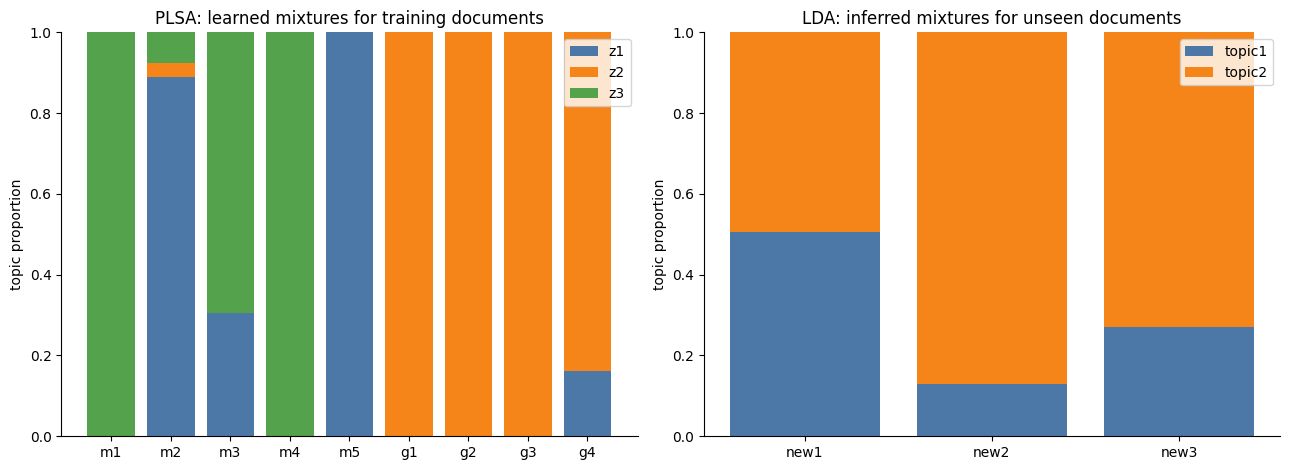

In [179]:
# Reuse earlier PLSA-style factors and LDA new-doc inference
plsa_train_doc_mix = Pz_d.copy()  # topics x docs
new_docs = [
    "user interface response",
    "graph trees minors",
    "survey of computer system",
]
new_X_counts = cv_lda.transform(new_docs)
new_doc_topic = lda.transform(new_X_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# PLSA training docs only
ax = axes[0]
bottom = np.zeros(plsa_train_doc_mix.shape[1])
colors = ["#4C78A8", "#F58518", "#54A24B"]
for k in range(plsa_train_doc_mix.shape[0]):
    ax.bar(doc_names, plsa_train_doc_mix[k], bottom=bottom, label=f"z{k+1}", color=colors[k % len(colors)])
    bottom += plsa_train_doc_mix[k]
ax.set_ylim(0, 1)
ax.set_title("PLSA: learned mixtures for training documents")
ax.set_ylabel("topic proportion")
ax.legend()

# LDA new docs
ax = axes[1]
bottom = np.zeros(new_doc_topic.shape[0])
colors = ["#4C78A8", "#F58518"]
for k in range(new_doc_topic.shape[1]):
    ax.bar([f"new{i+1}" for i in range(len(new_docs))], new_doc_topic[:, k], bottom=bottom, label=f"topic{k+1}", color=colors[k])
    bottom += new_doc_topic[:, k]
ax.set_ylim(0, 1)
ax.set_title("LDA: inferred mixtures for unseen documents")
ax.set_ylabel("topic proportion")
ax.legend()

plt.tight_layout()
plt.show()


In [180]:
new_docs = [
    "user interface response",
    "graph trees minors",
    "survey of computer system",
]
new_X_counts = cv_lda.transform(new_docs)
new_doc_topic = lda.transform(new_X_counts)

pd.DataFrame(new_doc_topic, index=[f"new{i+1}" for i in range(len(new_docs))], columns=["topic1","topic2"]).round(3)


,topic1,topic2
new1,0.505,0.495
new2,0.128,0.872
new3,0.271,0.729


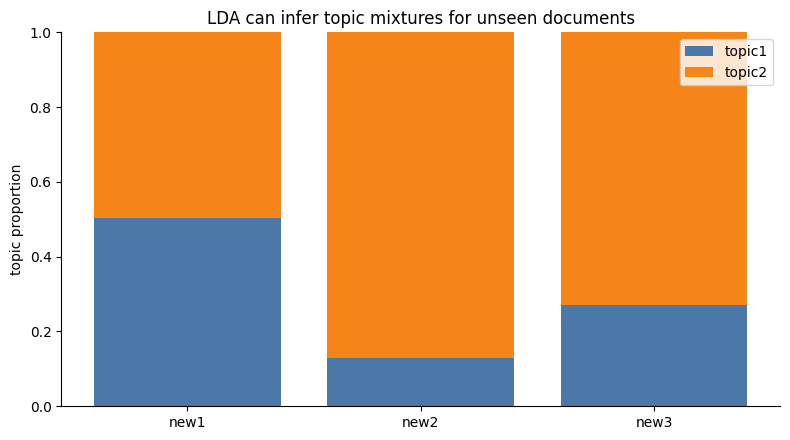

In [181]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bottom = np.zeros(len(new_docs))
colors = ["#4C78A8", "#F58518"]
for k in range(new_doc_topic.shape[1]):
    ax.bar([f"new{i+1}" for i in range(len(new_docs))], new_doc_topic[:, k], bottom=bottom, label=f"topic{k+1}", color=colors[k])
    bottom += new_doc_topic[:, k]
ax.set_ylim(0, 1)
ax.set_ylabel("topic proportion")
ax.set_title("LDA can infer topic mixtures for unseen documents")
ax.legend()
plt.tight_layout()
plt.show()


## 16. Slide: Summary

A compact final output for classroom discussion.


In [182]:
print("Takeaway:")
print("- Topic modelling is unsupervised document clustering / soft clustering.")
print("- LSA uses linear algebra but concepts can have negative weights and be hard to interpret.")
print("- NMF gives non-negative topics, which are easier to read as parts-based topics.")
print("- PLSA introduces hidden topics probabilistically, but document parameters grow with the dataset.")
print("- LDA adds Dirichlet priors, giving better generalization to new documents.")


Takeaway:
- Topic modelling is unsupervised document clustering / soft clustering.
- LSA uses linear algebra but concepts can have negative weights and be hard to interpret.
- NMF gives non-negative topics, which are easier to read as parts-based topics.
- PLSA introduces hidden topics probabilistically, but document parameters grow with the dataset.
- LDA adds Dirichlet priors, giving better generalization to new documents.
